In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
lime = pd.read_csv("../data/df_all_lime.csv")

In [3]:
lime = lime.rename(columns={
    "LATITUDINE_INIZIO_CORSA": "start_lat",
    "LONGITUTIDE_INIZIO_CORSA": "start_lon",
    "LATITUDINE_FINE_CORSA": "end_lat",
    "LONGITUTIDE_FINE_CORSA": "end_lon",
    "DATAORA_INIZIO": "start_time",
    "DATAORA_FINE": "end_time"
})


In [4]:
lime["start_time"] = pd.to_datetime(lime["start_time"])
lime["end_time"]   = pd.to_datetime(lime["end_time"])

In [5]:
print("\nlime columns:\n", lime.columns)


lime columns:
 Index(['ID_ORGANIZZAZIONE', 'ID_VEICOLO', 'start_time', 'end_time',
       'start_lat', 'start_lon', 'end_lat', 'end_lon', 'PERCORSO',
       'DISTANZA_KM', 'DURATA_MIN', 'RISERVATO', 'BATTERIA_INIZIO_CORSA',
       'BATTERIA_FINE_CORSA', 'DURATA_H', 'SPEED_KMH', 'YEAR', 'MONTH', 'HOUR',
       'WEEKDAY', 'DAY', 'YEAR_MONTH', 'IS_WEEKEND', 'WEEK'],
      dtype='str')


In [6]:
lime = lime.sort_values(by=['ID_VEICOLO', 'start_time'])

In [7]:
lime[['ID_VEICOLO', 'start_time', 'end_time']].head(20)

,ID_VEICOLO,start_time,end_time
61274,AAWASE,2024-02-12 18:47:40,2024-02-12 19:03:46
61767,AAWASE,2024-02-13 00:20:35,2024-02-13 00:25:05
62248,AAWASE,2024-02-13 12:03:37,2024-02-13 12:07:51
62920,AAWASE,2024-02-13 18:37:22,2024-02-13 18:52:26
63001,AAWASE,2024-02-13 19:08:53,2024-02-13 19:12:24
63327,AAWASE,2024-02-13 22:12:54,2024-02-13 22:27:17
64760,AAWASE,2024-02-14 18:35:44,2024-02-14 18:53:17
68945,AAWASE,2024-02-16 19:52:09,2024-02-16 19:55:57
69126,AAWASE,2024-02-16 21:16:20,2024-02-16 21:26:24
69319,AAWASE,2024-02-16 22:43:20,2024-02-16 22:53:11


In [8]:
lime.sort_values(by='start_time').head(20)

,ID_ORGANIZZAZIONE,ID_VEICOLO,start_time,end_time,start_lat,start_lon,end_lat,end_lon,PERCORSO,DISTANZA_KM,...,DURATA_H,SPEED_KMH,YEAR,MONTH,HOUR,WEEKDAY,DAY,YEAR_MONTH,IS_WEEKEND,WEEK
0,NaN,DDLZXF,2024-01-01 00:01:44,2024-01-01 00:10:13,45.075839,7.675694,45.069034,7.704333,"{\n ""coordinates"": [\n [\n 7.67572,\n...",3,...,0.133333,22.500000,2024,2024-01,0,Monday,1,2024-01,False,2024-01-01/2024-01-07
1,NaN,LLCXKX,2024-01-01 00:02:09,2024-01-01 00:08:22,45.088620,7.689256,45.097376,7.697247,"{\n ""coordinates"": [\n [\n 7.68938,\n...",1,...,0.100000,10.000000,2024,2024-01,0,Monday,1,2024-01,False,2024-01-01/2024-01-07
2,NaN,TXYHWJ,2024-01-01 00:04:29,2024-01-01 00:08:59,45.068765,7.689190,45.068296,7.683335,"{\n ""coordinates"": [\n [\n 7.68918,\n...",1,...,0.083333,12.000000,2024,2024-01,0,Monday,1,2024-01,False,2024-01-01/2024-01-07
3,NaN,NKTZFM,2024-01-01 00:05:02,2024-01-01 00:07:51,45.103594,7.650629,45.099483,7.642616,"{\n ""coordinates"": [\n [\n 7.65072,\n...",1,...,0.050000,20.000000,2024,2024-01,0,Monday,1,2024-01,False,2024-01-01/2024-01-07
4,NaN,QNMNZN,2024-01-01 00:05:29,2024-01-01 00:16:28,45.089189,7.677439,45.089605,7.663940,"{\n ""coordinates"": [\n [\n 7.67741,\n...",1,...,0.183333,5.454545,2024,2024-01,0,Monday,1,2024-01,False,2024-01-01/2024-01-07
5,NaN,SKDHAU,2024-01-01 00:07:44,2024-01-01 00:23:43,45.064871,7.693544,45.043031,7.675444,"{\n ""coordinates"": [\n [\n 7.69354,\n...",3,...,0.266667,11.250000,2024,2024-01,0,Monday,1,2024-01,False,2024-01-01/2024-01-07
6,NaN,DGXPKS,2024-01-01 00:07:50,2024-01-01 00:23:05,45.064923,7.693551,45.043052,7.675432,"{\n ""coordinates"": [\n [\n 7.69353,\n...",3,...,0.250000,12.000000,2024,2024-01,0,Monday,1,2024-01,False,2024-01-01/2024-01-07
7,NaN,RVUYKR,2024-01-01 00:08:11,2024-01-01 00:14:44,45.069337,7.693109,45.068867,7.686432,"{\n ""coordinates"": [\n [\n 7.69303,\n...",1,...,0.116667,8.571429,2024,2024-01,0,Monday,1,2024-01,False,2024-01-01/2024-01-07
8,NaN,HNMZHK,2024-01-01 00:08:29,2024-01-01 00:16:15,45.072141,7.694790,45.078403,7.679090,"{\n ""coordinates"": [\n [\n 7.69483,\n...",1,...,0.133333,7.500000,2024,2024-01,0,Monday,1,2024-01,False,2024-01-01/2024-01-07
9,NaN,SYZVUN,2024-01-01 00:09:25,2024-01-01 00:14:42,45.069932,7.691695,45.068851,7.686413,"{\n ""coordinates"": [\n [\n 7.69172,\n...",1,...,0.083333,12.000000,2024,2024-01,0,Monday,1,2024-01,False,2024-01-01/2024-01-07


In [9]:
lime['next_start_time'] = lime.groupby('ID_VEICOLO')['start_time'].shift(-1)

lime['parking_duration'] = lime['next_start_time'] - lime['end_time']

In [10]:
lime['parking_minutes'] = lime['parking_duration'].dt.total_seconds() / 60

In [11]:
lime[['ID_VEICOLO', 'end_time', 'next_start_time', 'parking_minutes']].head(20)

,ID_VEICOLO,end_time,next_start_time,parking_minutes
61274,AAWASE,2024-02-12 19:03:46,2024-02-13 00:20:35,316.816667
61767,AAWASE,2024-02-13 00:25:05,2024-02-13 12:03:37,698.533333
62248,AAWASE,2024-02-13 12:07:51,2024-02-13 18:37:22,389.516667
62920,AAWASE,2024-02-13 18:52:26,2024-02-13 19:08:53,16.450000
63001,AAWASE,2024-02-13 19:12:24,2024-02-13 22:12:54,180.500000
63327,AAWASE,2024-02-13 22:27:17,2024-02-14 18:35:44,1208.450000
64760,AAWASE,2024-02-14 18:53:17,2024-02-16 19:52:09,2938.866667
68945,AAWASE,2024-02-16 19:55:57,2024-02-16 21:16:20,80.383333
69126,AAWASE,2024-02-16 21:26:24,2024-02-16 22:43:20,76.933333
69319,AAWASE,2024-02-16 22:53:11,2024-02-16 23:10:46,17.583333


In [33]:
lime_clean = lime[
    (lime['parking_minutes'] > 0) & 
    (lime['parking_minutes'] < 10000)
]

In [13]:
from shapely.geometry import Point

lime['geometry'] = lime.apply(
    lambda row: Point(float(row['end_lon']), float(row['end_lat'])),
    axis=1
)

lime_gdf = gpd.GeoDataFrame(lime, geometry='geometry', crs='EPSG:4326')

In [14]:
zones = gpd.read_file("/Users/mina/Desktop/EX4/Turin_Zone.gpkg")

In [15]:
zones = zones.to_crs(lime_gdf.crs)

In [16]:
lime_zones = gpd.sjoin(lime_gdf, zones, how='left', predicate='within')

In [17]:
lime_zones.head()

,ID_ORGANIZZAZIONE,ID_VEICOLO,start_time,end_time,start_lat,start_lon,end_lat,end_lon,PERCORSO,DISTANZA_KM,...,YEAR_MONTH,IS_WEEKEND,WEEK,next_start_time,parking_duration,parking_minutes,geometry,index_right,ZONASTAT,DENOM
61274,NaN,AAWASE,2024-02-12 18:47:40,2024-02-12 19:03:46,45.062685,7.679245,45.044597,7.661126,"{\n ""coordinates"": [\n [\n 7.67922,\n...",3,...,2024-02,False,2024-02-12/2024-02-18,2024-02-13 00:20:35,0 days 05:16:49,316.816667,POINT (7.66113 45.0446),57.0,56,Mercato Ortofrutticolo
61767,NaN,AAWASE,2024-02-13 00:20:35,2024-02-13 00:25:05,45.041858,7.657518,45.042848,7.670643,"{\n ""coordinates"": [\n [\n 7.65755,\n...",1,...,2024-02,False,2024-02-12/2024-02-18,2024-02-13 12:03:37,0 days 11:38:32,698.533333,POINT (7.67064 45.04285),34.0,20,Corso Dante - Ponte Isabella
62248,NaN,AAWASE,2024-02-13 12:03:37,2024-02-13 12:07:51,45.042922,7.670419,45.047062,7.662349,"{\n ""coordinates"": [\n [\n 7.67038,\n...",1,...,2024-02,False,2024-02-12/2024-02-18,2024-02-13 18:37:22,0 days 06:29:31,389.516667,POINT (7.66235 45.04706),47.0,54,Stadio Comunale
62920,NaN,AAWASE,2024-02-13 18:37:22,2024-02-13 18:52:26,45.047044,7.662316,45.076128,7.684791,"{\n ""coordinates"": [\n [\n 7.66233,\n...",4,...,2024-02,False,2024-02-12/2024-02-18,2024-02-13 19:08:53,0 days 00:16:27,16.450000,POINT (7.68479 45.07613),13.0,01,Municipio
63001,NaN,AAWASE,2024-02-13 19:08:53,2024-02-13 19:12:24,45.076106,7.684813,45.072032,7.682622,"{\n ""coordinates"": [\n [\n 7.6849,\n ...",1,...,2024-02,False,2024-02-12/2024-02-18,2024-02-13 22:12:54,0 days 03:00:30,180.500000,POINT (7.68262 45.07203),13.0,01,Municipio


In [18]:
lime_zones.columns

Index(['ID_ORGANIZZAZIONE', 'ID_VEICOLO', 'start_time', 'end_time',
       'start_lat', 'start_lon', 'end_lat', 'end_lon', 'PERCORSO',
       'DISTANZA_KM', 'DURATA_MIN', 'RISERVATO', 'BATTERIA_INIZIO_CORSA',
       'BATTERIA_FINE_CORSA', 'DURATA_H', 'SPEED_KMH', 'YEAR', 'MONTH', 'HOUR',
       'WEEKDAY', 'DAY', 'YEAR_MONTH', 'IS_WEEKEND', 'WEEK', 'next_start_time',
       'parking_duration', 'parking_minutes', 'geometry', 'index_right',
       'ZONASTAT', 'DENOM'],
      dtype='str')

In [19]:
avg_parking = lime_zones.groupby('ZONASTAT')['parking_minutes'].mean().reset_index()

In [20]:
avg_parking.head()

,ZONASTAT,parking_minutes
0,01,377.288995
1,02,509.667787
2,03,426.915134
3,04,427.615653
4,05,520.594382


In [21]:
zones_avg = zones.merge(avg_parking, on='ZONASTAT', how='left')

In [29]:
zones_avg[['ZONASTAT', 'parking_minutes']].head()

,ZONASTAT,parking_minutes
0,70,1340.559483
1,42,636.910055
2,55,1059.826348
3,06,340.767206
4,09,359.059211


In [30]:
pip install mapclassify

  Using cached mapclassify-2.10.0-py3-none-any.whl.metadata (3.1 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached scikit_learn-1.8.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached mapclassify-2.10.0-py3-none-any.whl (882 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached scikit_learn-1.8.0-cp314-cp314-macosx_12_0_arm64.whl (8.1 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [mapclassify] [scikit-learn]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


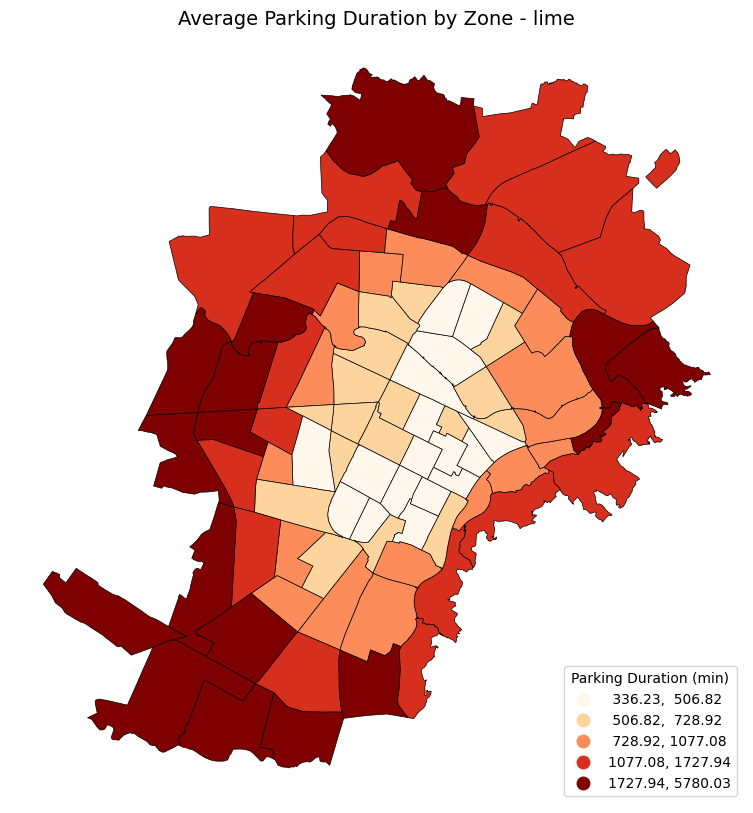

In [31]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10,10))

zones_avg.plot(
    column='parking_minutes',
    cmap='OrRd',
    scheme='quantiles',   # تقسیم به کلاس
    k=5,                  # تعداد کلاس‌ها
    linewidth=0.5,
    edgecolor='black',
    legend=True,
    legend_kwds={
        'title': 'Parking Duration (min)',
        'loc': 'lower right'
    },
    ax=ax
)

ax.set_title('Average Parking Duration by Zone - lime', fontsize=14)
ax.axis('off')

plt.show()

In [24]:
import folium

# ساخت نقشه پایه (مرکز تورین)
m = folium.Map(location=[45.07, 7.68], zoom_start=12)

# اضافه کردن choropleth
folium.Choropleth(
    geo_data=zones_avg,
    data=zones_avg,
    columns=['ZONASTAT', 'parking_minutes'],
    key_on='feature.properties.ZONASTAT',
    fill_color='OrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Average Parking Duration (minutes)'
).add_to(m)

m

In [32]:
zones_avg.to_file("lime_parking.geojson", driver="GeoJSON")